In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [23]:
from aeon.transformations.collection import Normalizer
from aeon.classification.distance_based import ProximityForest
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score, PrecisionRecallDisplay

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_array = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

This is also a distance based model that creates an ensemble of decision trees where the splits are based on the similarity between time series measured using various distance measures (dtw with and without constraints, dtw on differentiated time series, edit distance, longest matching subsequence, etc).

We run Proximity forest using the default parameters that were tuned on the usual suite of datasets.

Since this algorithm is slower, instead of using kfold cross validation for the evaluation of the model, we use holdout validation, reserving 25% of the training set for validation.

In [6]:
?ProximityForest

Init signature:
ProximityForest(
    n_trees=100,
    n_splitters: int = 5,
    max_depth: Optional[int] = None,
    min_samples_split: int = 2,
    random_state: Union[int, numpy.random.mtrand.RandomState, NoneType] = None,
    n_jobs: int = 1,
    parallel_backend=None,
)
Docstring:     
Proximity Forest Classifier.

The Proximity Forest is a distance-based classifier that creates an
ensemble of decision trees, where the splits are based on the
similarity between time series measured using various parameterised
distance measures.

Parameters
----------
n_trees: int, default = 100
    The number of trees, by default an ensemble of ``100`` trees is formed.
n_splitters: int, default = 5
    The number of candidate splitters to be evaluated at each node.
max_depth: int, default = None
    The maximum depth of the tree. If ``None``, then nodes are expanded until all
    leaves are pure or until all leaves contain less than ``min_samples_split``
    samples.
min_samples_split: int, default

## Rating Category

In [7]:
target = train['rating_category']
train_X, validation_X, train_y, validation_y = train_test_split(train_array, target,
                                                                stratify=target,
                                                                shuffle=True, random_state=42)
train_X.shape, train_y.shape, validation_X.shape, validation_y.shape

((637, 1, 100), (637,), (213, 1, 100), (213,))

In [8]:
rating_encoder = LabelEncoder()
train_y = rating_encoder.fit_transform(train_y)
rating_y_true = rating_encoder.transform(validation_y)

In [9]:
%%time
rating_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42))
])

rating_estimator.fit(train_X, train_y)

CPU times: user 22min 44s, sys: 24.3 s, total: 23min 8s
Wall time: 22min 30s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf', ProximityForest(n_jobs=-1, random_state=42))])

In [10]:
rating_y_pred = rating_estimator.predict(validation_X)

In [11]:
print(classification_report(y_true=rating_y_true, y_pred=rating_y_pred))

              precision    recall  f1-score   support

           0       0.52      0.62      0.57        71
           1       0.00      0.00      0.00         2
           2       0.38      0.53      0.44        73
           3       0.25      0.09      0.14        43
           4       0.30      0.12      0.18        24

    accuracy                           0.42       213
   macro avg       0.29      0.27      0.26       213
weighted avg       0.39      0.42      0.39       213



/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

In [12]:
rating_encoder.classes_

array(['High', 'Low', 'Medium', 'Medium High', 'Medium Low'], dtype=object)

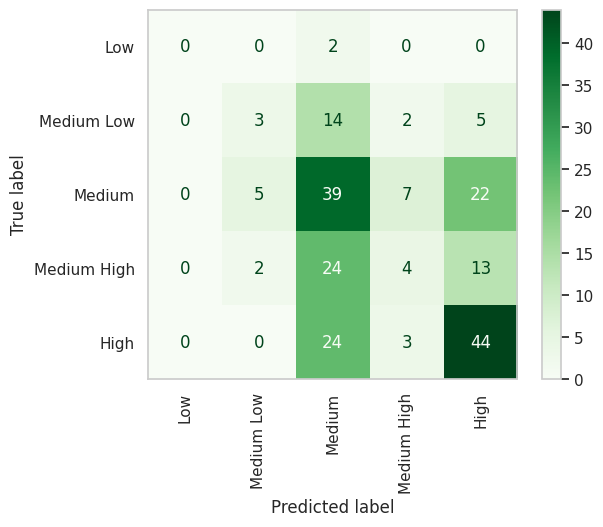

In [13]:
g = ConfusionMatrixDisplay.from_predictions(y_true=rating_y_true, y_pred=rating_y_pred, cmap='Greens',
                                        display_labels=('Low', 'Medium Low', 'Medium', 'Medium High', 'High'), xticks_rotation='vertical',
                                        labels=(1, 4, 2, 3, 0)
                                        )
g.ax_.grid(False)

In [14]:
train_predict = rating_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict,average='macro'))

Performance on the training set
Accuracy: 0.9968602825745683
F1 score: 0.9969246629141619


## Action

In [15]:
target = train['action']
train_X, validation_X, train_y, validation_y = train_test_split(train_array, target,
                                                                stratify=target,
                                                                shuffle=True, random_state=42)
train_X.shape, train_y.shape, validation_X.shape, validation_y.shape

((637, 1, 100), (637,), (213, 1, 100), (213,))

In [16]:
action_encoder = LabelEncoder()
train_y = action_encoder.fit_transform(train_y)
action_y_true = action_encoder.transform(validation_y)

In [17]:
%%time
action_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42))
])

action_estimator.fit(train_X, train_y)

CPU times: user 20min 47s, sys: 23 s, total: 21min 10s
Wall time: 20min 42s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf', ProximityForest(n_jobs=-1, random_state=42))])

In [18]:
action_y_pred = action_estimator.predict(validation_X)

In [19]:
print(classification_report(y_true=action_y_true, y_pred=action_y_pred))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       145
           1       0.68      0.40      0.50        68

    accuracy                           0.75       213
   macro avg       0.72      0.65      0.67       213
weighted avg       0.73      0.75      0.72       213



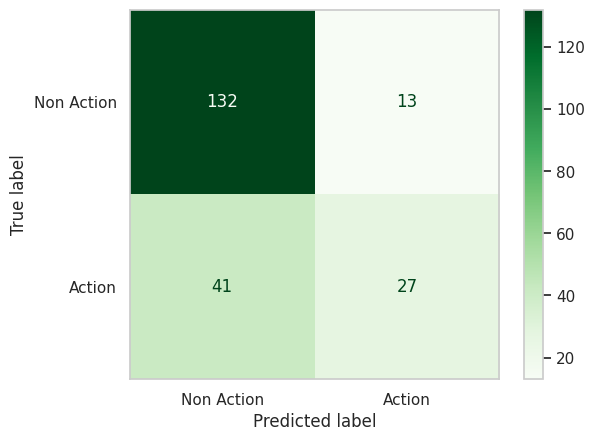

In [20]:
g = ConfusionMatrixDisplay.from_predictions(y_true=action_y_true, y_pred=action_y_pred, cmap='Greens', display_labels=('Non Action', 'Action'))
g.ax_.grid(False)

In [22]:
train_predict = action_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict))

Performance on the training set
Accuracy: 0.9968602825745683
F1 score: 0.9950248756218906


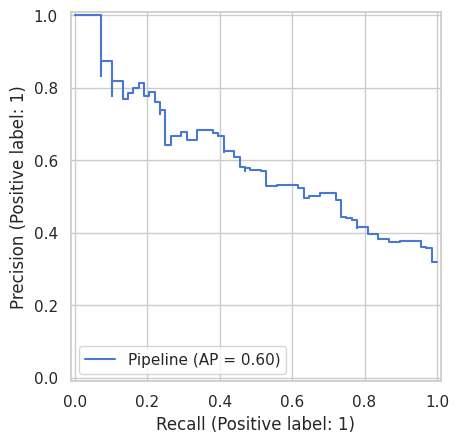

In [24]:
PrecisionRecallDisplay.from_estimator(action_estimator, validation_X, action_y_true)